In [1]:
#@title Setup code (Same as labs)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

from torchsummary import summary

from torchvision.datasets import FashionMNIST, MNIST
from torchvision.transforms import Compose, Normalize, ToTensor

from fastprogress.fastprogress import master_bar, progress_bar
data_path = '/tmp/data'
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# Use the GPUs if they are available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using '{device}' device.")

# Mini-Batch SGD hyperparameters
batch_size = 256
num_epochs = 10
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()

def get_fmnist_data_loaders(path, batch_size, valid_batch_size=0):
    # Computing normalization constants for Fashion-MNIST (commented out since we only need to do this once)
    # train_loader, valid_loader = get_fmnist_data_loaders(data_path, 0)
    # X, _ = next(iter(train_loader))
    # s, m = torch.std_mean(X)


    # Data specific transforms
    data_mean = (0.2860,)
    data_std = (0.3530,)
    xforms = Compose([ToTensor(), Normalize(data_mean, data_std)])

    # Training data loader
    train_dataset = MNIST(root=path, train=True, download=True, transform=xforms)

    # Set the batch size to N if batch_size is 0
    tbs = len(train_dataset) if batch_size == 0 else batch_size
    train_loader = DataLoader(train_dataset, batch_size=tbs, shuffle=True)

    # Validation data loader
    valid_dataset = MNIST(root=path, train=False, download=True, transform=xforms)

    # Set the batch size to N if batch_size is 0
    vbs = len(valid_dataset) if valid_batch_size == 0 else valid_batch_size
    valid_loader = DataLoader(valid_dataset, batch_size=vbs, shuffle=True)

    return train_loader, valid_loader

from torch.optim import Adam

def nll_loss(model, X, Y):
    # Compute the output
    train_output = model(X)

    # Compute loss
    train_loss = criterion(train_output, Y)
    return train_output, train_loss

# Here we'll define a function to train and evaluate a neural network with a specified architecture
# using a specified optimizer.
def run_model(data_path, model, optimizer=Adam, learning_rate=0.001,
              get_output_and_loss=nll_loss, extra_params=None):
    train_loader, valid_loader = get_fmnist_data_loaders(data_path, batch_size)
    return gradient_descent(model, train_loader, valid_loader, optimizer,
                            learning_rate, get_output_and_loss=get_output_and_loss,
                            extra_params=extra_params) 



def gradient_descent(model, train_loader, valid_loader, optimizer=Adam, learning_rate=0.001, get_output_and_loss=nll_loss, num_epochs=num_epochs, doprint=True, extra_params=None):

    # Do model creation here so that the model is recreated each time the cell is run
    model = model.to(device) 
    
    params = list(model.parameters())
    if extra_params is not None:
        params += list(extra_params)
    
    opt = optimizer(params, learning_rate)

    #t = 0
    # Create the optimizer, just like we have with the built-in optimizer
    #opt = optimizer(model.parameters(), learning_rate)

    # A master bar for fancy output progress
    mb = master_bar(range(num_epochs))

    # Information for plots
    mb.names = ["Train Loss", "Valid Loss"]
    train_losses = []
    valid_losses = []

    for epoch in mb:

        #
        # Training
        #
        model.train()

        train_N = len(train_loader.dataset)
        num_train_batches = len(train_loader)
        train_dataiterator = iter(train_loader)

        train_loss_mean = 0

        for batch in progress_bar(range(num_train_batches), parent=mb):

            # Grab the batch of data and send it to the correct device
            train_X, train_Y = next(train_dataiterator)
            train_X, train_Y = train_X.to(device), train_Y.to(device)

            train_output, train_loss = get_output_and_loss(model, train_X, train_Y)

            num_in_batch = len(train_X)
            tloss = train_loss.item() * num_in_batch / train_N
            train_loss_mean += tloss
            train_losses.append(train_loss.item())

            # Compute gradient
            model.zero_grad()
            train_loss.backward()

            # Take a step of gradient descent
            #t += 1
            with torch.no_grad():
                opt.step()

        #
        # Validation
        #
        model.eval()

        valid_N = len(valid_loader.dataset)
        num_valid_batches = len(valid_loader)

        valid_loss_mean = 0
        valid_correct = 0

        with torch.no_grad():

            # valid_loader is probably just one large batch, so not using progress bar
            for valid_X, valid_Y in valid_loader:

                valid_X, valid_Y = valid_X.to(device), valid_Y.to(device)

                valid_output, valid_loss = get_output_and_loss(model, valid_X, valid_Y)

                num_in_batch = len(valid_X)
                vloss = valid_loss.item() * num_in_batch / valid_N
                valid_loss_mean += vloss
                valid_losses.append(valid_loss.item())

                try:
                    # Convert network output into predictions (one-hot -> number)
                    predictions = valid_output.argmax(1)

                    # Sum up total number that were correct
                    valid_correct += (predictions == valid_Y).type(torch.float).sum().item()
                except:
                    pass

        valid_accuracy = 100 * (valid_correct / valid_N)

        # Report information
        tloss = f"Train Loss = {train_loss_mean:.4f}"
        vloss = f"Valid Loss = {valid_loss_mean:.4f}"
        vaccu = f"Valid Accuracy = {(valid_accuracy):>0.1f}%"
        if doprint:
            mb.write(f"[{epoch+1:>2}/{num_epochs}] {tloss}; {vloss}; {vaccu}")

        # Update plot data
        max_loss = max(max(train_losses), max(valid_losses))
        min_loss = min(min(train_losses), min(valid_losses))

        x_margin = 0.2
        x_bounds = [0 - x_margin, num_epochs + x_margin]

        y_margin = 0.1
        y_bounds = [min_loss - y_margin, max_loss + y_margin]

        valid_Xaxis = torch.linspace(0, epoch + 1, len(train_losses))
        valid_xaxis = torch.linspace(1, epoch + 1, len(valid_losses))
        graph_data = [[valid_Xaxis, train_losses], [valid_xaxis, valid_losses]]

        mb.update_graph(graph_data, x_bounds, y_bounds)

    if doprint:
        print(f"[{epoch+1:>2}/{num_epochs}] {tloss}; {vloss}; {vaccu}")


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def dodge_y(points, point_size, padding=0.0, anchor="bottom"):
    points = np.asarray(points)

    if points.ndim == 1:
        x = points.astype(float, copy=False)
    elif points.ndim == 2 and points.shape[1] >= 1:
        x = points[:, 0].astype(float, copy=False)
    else:
        raise ValueError(
            "points must be a 1D array of x positions or a 2D array with x in the first column"
        )

    if point_size < 0 or padding < 0:
        raise ValueError("point_size and padding must be non-negative")
    if anchor not in {"bottom", "middle", "top"}:
        raise ValueError("anchor must be 'bottom', 'middle', or 'top'")

    n = x.shape[0]
    y = np.zeros(n, dtype=float)
    separation = float(point_size + padding)

    if n == 0 or separation == 0:
        return y

    sep2 = separation * separation
    tol = 1e-12
    buckets = {}

    def pick_generic(dx, active_y):
        dy = np.sqrt(np.maximum(sep2 - dx * dx, 0.0))
        candidates = np.empty(2 * dx.size + 1, dtype=float)
        candidates[0] = 0.0
        candidates[1::2] = active_y - dy
        candidates[2::2] = active_y + dy

        best = None
        for yc in candidates:
            if anchor == "bottom" and yc < -tol:
                continue
            if anchor == "top" and yc > tol:
                continue

            if np.all(dx * dx + (yc - active_y) ** 2 >= sep2 - tol):
                yc = float(yc)
                if best is None:
                    best = yc
                elif anchor == "middle" and (abs(yc), yc) < (abs(best), best):
                    best = yc
                elif anchor == "bottom" and yc < best:
                    best = yc
                elif anchor == "top" and yc > best:
                    best = yc

        if best is None:
            raise RuntimeError("failed to place a point without overlap")
        return best

    for i, xi in enumerate(x):
        bucket = int(np.floor(xi / separation))
        neighbor_indices = []
        for b in (bucket - 1, bucket, bucket + 1):
            neighbor_indices.extend(buckets.get(b, ()))

        if neighbor_indices:
            active_idx = np.array(neighbor_indices, dtype=int)
            dx = xi - x[active_idx]
            keep = np.abs(dx) < separation
            active_idx = active_idx[keep]
            dx = dx[keep]

            if dx.size:
                active_y = y[active_idx]
                dy = np.sqrt(np.maximum(sep2 - dx * dx, 0.0))
                lower = active_y - dy
                upper = active_y + dy

                if anchor == "bottom":
                    yi = 0.0
                    while True:
                        blocked = (lower - tol <= yi) & (yi < upper - tol)
                        if not np.any(blocked):
                            break
                        yi = float(np.max(upper[blocked]))
                    y[i] = yi
                elif anchor == "top":
                    yi = 0.0
                    while True:
                        blocked = (lower + tol < yi) & (yi <= upper + tol)
                        if not np.any(blocked):
                            break
                        yi = float(np.min(lower[blocked]))
                    y[i] = yi
                else:
                    y[i] = pick_generic(dx, active_y)

        buckets.setdefault(bucket, []).append(i)

    return y


def patch_scatter(x, y, radius, ax=None, facecolor="C0", **kwargs):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape")
    if radius < 0:
        raise ValueError("radius must be non-negative")

    if ax is None:
        ax = plt.gca()

    patches = []
    for i, (xi, yi) in enumerate(zip(x.ravel(), y.ravel())):
        if facecolor is not None and isinstance(facecolor, np.ndarray):
            color = cmap = plt.get_cmap('tab10')(facecolor.ravel().astype(int)[i] % 10)
        else:
            color = facecolor
        patch = Circle((xi, yi), radius=radius, facecolor=color, **kwargs)
        ax.add_patch(patch)
        patches.append(patch)

    ax.autoscale_view()
    return ax, patches


def plotDataAndPdf(data=None, pdf=None, xlim=None, ax=None, datacolor="C0", pdfcolor="C1"):
    fig, ax = plt.subplots(figsize=(10, 3)) if ax is None else (ax.figure, ax)

    if not data is None:
        npoints = data.size()[0]
        min_x = data.min()
        max_x = data.max()
        width = max_x - min_x
        min_x -= 0.1 * width
        max_x += 0.1 * width

        radius = 5 *(width.item() / (npoints))

        data = torch.tensor(data).detach().cpu().numpy()
        datay = dodge_y(data, point_size=2. * radius)
        patch_scatter(data, datay, radius=radius, ax=ax, facecolor=datacolor)
        ax.set_aspect("equal")
        ax.yaxis.set_visible(False)
    else:
        min_x = -5
        max_x = 5
        npoints = 1
        radius = 1 / 2.25

    if xlim is not None:
        min_x, max_x = xlim
        ax.set_xlim(min_x, max_x)

    if not pdf is None:
        x = torch.linspace(min_x, max_x, 300)
        y = pdf(x).detach().cpu().numpy()
        x = x.detach().cpu().numpy()
        plt.plot(x, y * npoints * (2.25 * radius) ** 2, c=pdfcolor)

    plt.show()

Using 'cuda' device.


In [2]:
#@title A basic convolutional block we'll use in both models

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.activation = nn.SiLU()
        self.normalization = nn.InstanceNorm2d(out_channels)

    def forward(self, x):
        x = self.activation(self.normalization(self.conv1(x)))
        x = self.activation(self.normalization(self.conv2(x)))
        return x


# Variational Autoencoders

In [3]:
#@title Encoder and Decoder

encoder = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    ConvBlock(32, 32),
    nn.AvgPool2d(kernel_size=2, stride=2),
    ConvBlock(32, 64),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 160),
    nn.LayerNorm(160),
    nn.SiLU(),
    nn.Linear(160, 120),
    nn.SiLU(),
    nn.Linear(120, 100)
)

decoder = nn.Sequential(
    nn.Linear(50, 120),
    nn.SiLU(),
    nn.Linear(120, 160),
    nn.SiLU(),
    nn.Linear(160, 64 * 7 * 7),
    nn.SiLU(),
    nn.Unflatten(1, (64, 7, 7)),
    nn.Upsample(scale_factor=2, mode='nearest'),
    ConvBlock(64, 32),
    nn.Upsample(scale_factor=2, mode='nearest'),
    ConvBlock(32, 32),
    nn.Conv2d(32, 1, kernel_size=3, padding=1)
)

In [4]:
#@title VAE Model

class VariationalAutoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, X):
        mean, logvar = self.encoder(X) \
            .chunk(2, dim=1)               # Split the encoder output into mean and var
        std = torch.exp(0.5 * logvar)      # Calculate standard deviation
        eps = torch.randn_like(std)        # Sample from standard normal distribution
        z = mean + eps * std               # Reparameterization trick
        return self.decoder(z), mean, logvar

In [5]:
def discretized_gaussian_logprob(x, mean, log_sigma=None):
    # One pixel step in normalized space = 1/255 / std
    pixel_step = (1. / 255.) / 0.3530
    if log_sigma is None:
        upper = (x + 0.5 * pixel_step - mean)
        lower = (x - 0.5 * pixel_step - mean)
    else:
        sigma = log_sigma.exp()
        upper = (x + 0.5 * pixel_step - mean) / sigma
        lower = (x - 0.5 * pixel_step - mean) / sigma

    normal = torch.distributions.Normal(0, 1)
    log_prob = torch.log(torch.clamp(normal.cdf(upper) - normal.cdf(lower),min=1e-12)
    )
    return log_prob.sum(dim=(1, 2, 3))

def vae_vlb_loss(model, X, y):
    output, mean, logvar = model(X)
    # Proper discretized reconstruction loss — sum over dims, mean over batch
    recon = -discretized_gaussian_logprob(X, output).mean()

    # KL divergence — sum over latent dims, mean over batch
    kl = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp(),dim=1).mean()

    loss = recon + kl
    return output, loss

In [6]:
#@title Sampling function

def sample(self, num_samples):
    z = torch.randn(num_samples, self.encoder[-1].out_features // 2).cuda()  # Sample from standard normal distribution
    return self.decoder(z)

VariationalAutoencoder.sample = sample

<div><p>[ 1/10] Train Loss = 4405.0908; Valid Loss = 4354.9565; Valid Accuracy = 0.0%</p><p>[ 2/10] Train Loss = 4341.4216; Valid Loss = 4331.2290; Valid Accuracy = 0.0%</p><p>[ 3/10] Train Loss = 4324.5394; Valid Loss = 4322.4824; Valid Accuracy = 0.0%</p><p>[ 4/10] Train Loss = 4318.4492; Valid Loss = 4316.9092; Valid Accuracy = 0.0%</p><p>[ 5/10] Train Loss = 4315.6044; Valid Loss = 4314.4966; Valid Accuracy = 0.0%</p><p>[ 6/10] Train Loss = 4313.7592; Valid Loss = 4313.4155; Valid Accuracy = 0.0%</p><p>[ 7/10] Train Loss = 4312.2510; Valid Loss = 4311.8013; Valid Accuracy = 0.0%</p><p>[ 8/10] Train Loss = 4310.7959; Valid Loss = 4311.3779; Valid Accuracy = 0.0%</p><p>[ 9/10] Train Loss = 4309.4883; Valid Loss = 4309.6313; Valid Accuracy = 0.0%</p><p>[10/10] Train Loss = 4308.3919; Valid Loss = 4307.9492; Valid Accuracy = 0.0%</p></div>

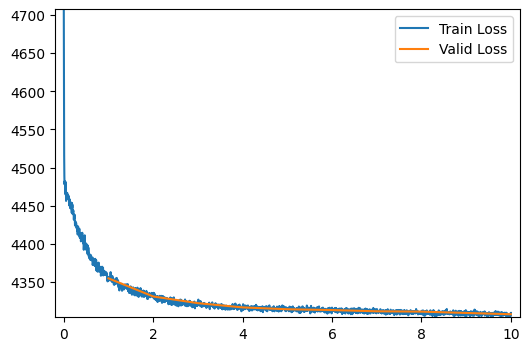

[10/10] Train Loss = 4308.3919; Valid Loss = 4307.9492; Valid Accuracy = 0.0%


In [7]:
#@title Train model on MNIST

vae_model = VariationalAutoencoder(encoder, decoder)
run_model(data_path, vae_model, learning_rate=0.003,
          get_output_and_loss=vae_vlb_loss)

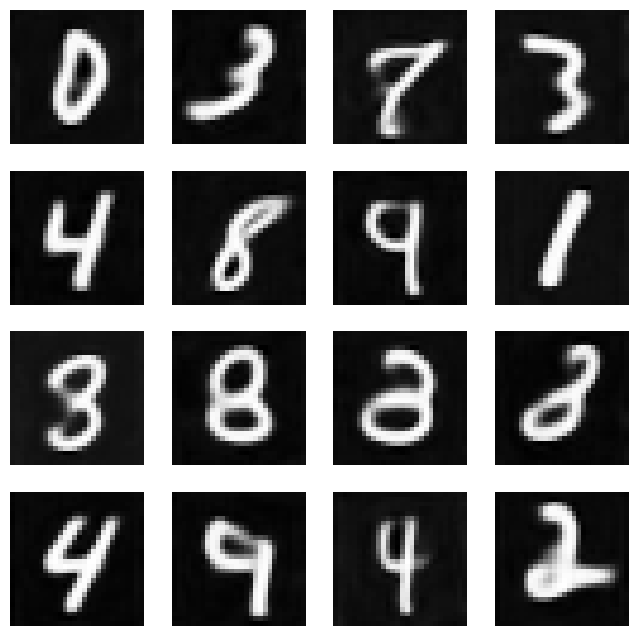

In [8]:
#@title Try sampling MNIST examples

X = vae_model.sample(num_samples=16)
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X[i][0].detach().cpu().numpy(), cmap='Greys_r')
    plt.axis('off')
plt.show()

# Diffusion Models

In [9]:
#@title UNet Implementation with Time Embedding


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Time embedding layer
        self.time_embedding = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
        )

        self.input_conv = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.output_conv = nn.Conv2d(32, 1, kernel_size=3, padding=1)

        # Define the UNet architecture here
        self.down_blocks = nn.ModuleList([
            ConvBlock(32, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128)
        ])

        self.up_blocks = nn.ModuleList([
            ConvBlock(128, 64),
            ConvBlock(64, 32),
            ConvBlock(32, 32)
        ])

    def forward(self, x, t):
        # Initial convolution to get the right number of channels
        x = self.input_conv(x)

        # Embed the time step and add it to the input
        t_emb = self.time_embedding(t.reshape(-1, 1))  # Embed time step
        t_emb = t_emb.view(t_emb.size(0), t_emb.size(1), 1, 1)  # Reshape for broadcasting
        x = x + t_emb

        # Downsample
        skip_connections = []
        for block in self.down_blocks[:-1]:  # Exclude the last block for skip connections
            x = block(x)
            skip_connections.append(x)
            x = nn.MaxPool2d(2)(x)

        x = self.up_blocks[0](self.down_blocks[-1](x))  # Process the bottleneck

        # Upsample
        for i, block in enumerate(self.up_blocks[1:]):  # Exclude the first block for skip connections
            x = nn.Upsample(scale_factor=2, mode='nearest')(x)
            x = block(x + skip_connections[-(i+1)])  # Add skip connection
        x = self.output_conv(x)
        return x


In [10]:
def diffusion_vlb_loss(model, X, y):
    device = X.device
    t = torch.rand(X.size(0), device= device) * 0.998 + 0.001 
    t_shaped = t[:, None, None, None]
    
    eps = torch.randn_like(X)
    z_t = (1 - t_shaped) * X + t_shaped * eps
    x_hat = model(z_t, t)

    # Diffusion Loss 
    snr_weight = torch.clamp((1 - t) / (t ** 3), max=1e3)
    mse_per_image = ((x_hat - X) ** 2).sum(dim=(1, 2, 3))  # sum isntead of mean
    diff_loss = (snr_weight * mse_per_image).mean()

    # Reconstruction loss
    t_small   = torch.full((X.size(0),), 0.001, device=device)
    t_small_b = t_small[:, None, None, None]
    z_0       = (1 - t_small_b) * X + t_small_b * torch.randn_like(X)
    x_hat_0   = model(z_0, t_small)
    recon_loss = -discretized_gaussian_logprob(X, x_hat_0).mean()

    return x_hat, diff_loss + recon_loss

In [11]:
#@title Sampling function

def sample_diffusion(model, num_samples, steps=100):
    x = torch.zeros(num_samples, 1, 28, 28).cuda()                                    # Start with pure noise
    for t in tqdm(torch.linspace(1., 0.01, steps=steps).cuda(), desc="Sampling"):     # Gradually reduce noise
        x_t = (1 - t) * x + t * torch.randn_like(x)                                   # Current noisy image
        x = model(x_t, t)                                                             # Get the denoised output at each step
    return x

<div><p>[ 1/10] Train Loss = 8294.6142; Valid Loss = 5412.5059; Valid Accuracy = 0.0%</p><p>[ 2/10] Train Loss = 5061.9642; Valid Loss = 4881.0845; Valid Accuracy = 0.0%</p><p>[ 3/10] Train Loss = 4877.9530; Valid Loss = 4811.7935; Valid Accuracy = 0.0%</p><p>[ 4/10] Train Loss = 4739.7512; Valid Loss = 4728.7651; Valid Accuracy = 0.0%</p><p>[ 5/10] Train Loss = 4724.5747; Valid Loss = 4737.0352; Valid Accuracy = 0.0%</p><p>[ 6/10] Train Loss = 4697.9311; Valid Loss = 4712.4658; Valid Accuracy = 0.0%</p><p>[ 7/10] Train Loss = 4675.0137; Valid Loss = 4614.0786; Valid Accuracy = 0.0%</p><p>[ 8/10] Train Loss = 4674.2473; Valid Loss = 4633.1128; Valid Accuracy = 0.0%</p><p>[ 9/10] Train Loss = 4629.5087; Valid Loss = 4588.2637; Valid Accuracy = 0.0%</p><p>[10/10] Train Loss = 4610.7076; Valid Loss = 4567.9360; Valid Accuracy = 0.0%</p></div>

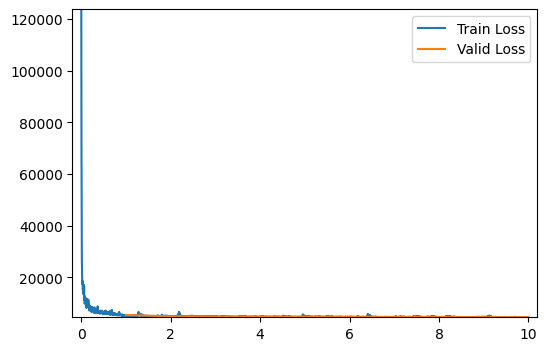

[10/10] Train Loss = 4610.7076; Valid Loss = 4567.9360; Valid Accuracy = 0.0%


In [12]:
#@title Train model on MNIST

unet_model = UNet()
run_model(data_path, unet_model, learning_rate=0.003,
          get_output_and_loss=diffusion_vlb_loss)

Sampling: 100%|█████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 660.53it/s]


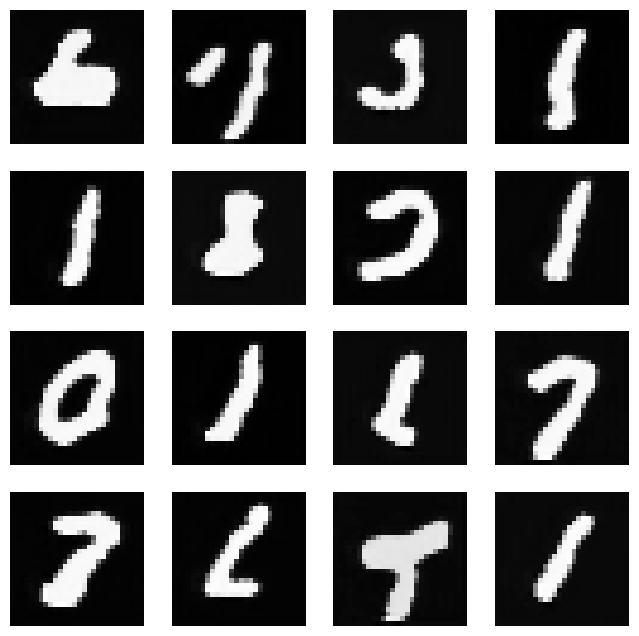

In [13]:

#@title Try sampling MNIST examples

X = sample_diffusion(unet_model, num_samples=16, steps=100)
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X[i][0].detach().cpu().numpy(), cmap='Greys_r')
    plt.axis('off')
plt.show()


# Variational Diffusion Models

# Noise Schedule Neural Network

In [14]:
import torch.nn.functional as F

class PositiveLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.bias   = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return F.linear(x, self.weight.abs(), self.bias)


class NoiseSchedule(nn.Module):
    def __init__(self, gamma_min_init=-6.0, gamma_max_init=6.0, hidden_dim=1024):
        super().__init__()
        self.gamma_min = nn.Parameter(torch.tensor(float(gamma_min_init)))
        self.gamma_max = nn.Parameter(torch.tensor(float(gamma_max_init)))
        self.l1 = PositiveLinear(1, 1)
        self.l2 = PositiveLinear(1, hidden_dim)
        self.l3 = PositiveLinear(hidden_dim, 1)

    def _gamma_tilde(self, t):
        t = t.view(-1, 1)
        h = self.l1(t)
        _h = 2. * (t - 0.5)                          # scale input to [-1, 1]
        _h = self.l2(_h)
        _h = 2. * (torch.sigmoid(_h) - 0.5)          # stable alternative to tanh
        _h = self.l3(_h) / self.l2.weight.shape[0]   # normalize by hidden_dim
        h = h + _h
        return h.squeeze(-1)

    def forward(self, t):
        zeros = torch.zeros(1, device=t.device, dtype=t.dtype)
        ones  = torch.ones( 1, device=t.device, dtype=t.dtype)
        g_t = self._gamma_tilde(t)
        g_0 = self._gamma_tilde(zeros)
        g_1 = self._gamma_tilde(ones)
        normed = (g_t - g_0) / (g_1 - g_0)
        return self.gamma_min + (self.gamma_max - self.gamma_min) * normed


# Fourier Feature Stuff

In [15]:
class FourierFeatures(nn.Module):
    def __init__(self, start=6, stop=8, step=1):
        super().__init__()
        freqs = range(start, stop, step)
        w = 2. ** torch.tensor(list(freqs), dtype=torch.float32) * 2 * torch.pi
        self.register_buffer('w', w)   # not a parameter; moves with .to(device)

    def forward(self, z):
        """
        z:      (B, C, H, W)
        return: (B, C * 2 * num_freqs, H, W)
        """
        B, C, H, W = z.shape
        num_freqs = self.w.shape[0]
        h = z.repeat_interleave(num_freqs, dim=1)
        w = self.w.repeat(C)
        w = w.view(1, -1, 1, 1) 
        h = h * w 
        return torch.cat([torch.sin(h), torch.cos(h)], dim=1)  # (B, C*2*num_freqs, H, W)

    @property
    def out_multiplier(self):
        return 2 * self.w.shape[0]

In [16]:
class VDMUNet(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        # Fourier features expand the input channel count
        self.fourier  = FourierFeatures(4, 7, 1)
        total_in      = in_channels * (1 + self.fourier.out_multiplier)

        # UNet just takes γ_t instead of t
        self.gamma_embedding = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
        )

        self.input_conv  = nn.Conv2d(total_in,      32, kernel_size=3, padding=1)
        self.output_conv = nn.Conv2d(32, in_channels,   kernel_size=3, padding=1)

        # Define the UNet architecture here
        self.down_blocks = nn.ModuleList([
            ConvBlock(32, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128)
        ])

        self.up_blocks = nn.ModuleList([
            ConvBlock(128, 64),
            ConvBlock(64, 32),
            ConvBlock(32, 32)
        ])

    def forward(self, z, gamma):
        x = torch.cat([z, self.fourier(z)], dim=1)
        x = self.input_conv(x)
        g_emb = self.gamma_embedding(gamma.reshape(-1, 1))
        g_emb = g_emb.view(g_emb.size(0), g_emb.size(1), 1, 1)
        x = x + g_emb
        skip_connections = []
        for block in self.down_blocks[:-1]:
            x = block(x)
            skip_connections.append(x)
            x = nn.MaxPool2d(2)(x)
        x = self.up_blocks[0](self.down_blocks[-1](x))
        for i, block in enumerate(self.up_blocks[1:]):
            x = nn.Upsample(scale_factor=2, mode='nearest')(x)
            x = block(x + skip_connections[-(i + 1)])
        eps_pred = self.output_conv(x)
        return eps_pred 

In [17]:
def make_vdm_loss(schedule):
    def vdm_output_and_diffloss(model, X, y):
        device = X.device

        t = torch.rand(X.size(0), device = device) * 0.998 + 0.001
        g_t, g_t_grad = torch.func.jvp( 
            schedule, (t,),(torch.ones_like(t),)) #computes derivative of nn and output

        #calculate our values like in paper
        alpha_t = torch.sigmoid(-g_t).sqrt() #How much of OG image
        sigma_t = torch.sigmoid( g_t).sqrt() #How much noise gets added

        eps = torch.randn_like(X) #sapmle noise
        z_t = alpha_t[:, None, None, None] * X + sigma_t[:, None, None, None] * eps #Section 5 on paper

        eps_hat = model(z_t, g_t) #predict added noise

        mse_per_image = ((eps_hat - eps) ** 2).sum(dim=(1, 2, 3)) #diffusion loss
        diff_loss = (0.5 * g_t_grad * mse_per_image).mean() #Equation 17

        # Prior loss
        t_ones = torch.ones(X.size(0), device=device) #when t = 1
        g1  = schedule(t_ones) #give noise level at final time
        var_1  = torch.sigmoid(g1) 
        prior_loss = 0.5 * ( (1 - var_1)[:, None, None, None] * X ** 2+ var_1[:, None, None, None] - 1.0- torch.log(var_1[:, None, None, None])).sum(dim=(1, 2, 3)).mean()
        #the standard KL divergence between the final forward distribution and the standard normal prior.
        
        # Recon loss
        t_zero       = torch.zeros(X.size(0), device=device) #when latent is clean
        g_0          = schedule(t_zero) 
        log_sigma_0  = 0.5 * torch.log(torch.sigmoid(g_0))[:, None, None, None] #compute the log standard deviation at time 0.
        eps_0        = torch.randn_like(X)
        z_0_rescaled = X + log_sigma_0.exp() * eps_0
        recon_loss   = -discretized_gaussian_logprob(X, z_0_rescaled, log_sigma=log_sigma_0).mean()

        
        return eps_hat, diff_loss + prior_loss + recon_loss

    return vdm_output_and_diffloss

In [18]:
def sample_vdm(model, schedule, num_samples=16, steps=100, image_shape=(1, 28, 28)):
    model.eval()
    device = next(model.parameters()).device

    z  = torch.randn(num_samples, *image_shape, device=device)
    ts = torch.linspace(1., 1. / steps, steps=steps, device=device)

    for i, t_val in enumerate(tqdm(ts, desc="Sampling")):
        t = t_val.expand(num_samples)
        s = (t_val - 1. / steps).clamp(min=0.).expand(num_samples)

        g_t = schedule(t)
        g_s = schedule(s)

        alpha_s = torch.sigmoid(-g_s).sqrt()
        alpha_t = torch.sigmoid(-g_t).sqrt()
        sigma_t = torch.sigmoid( g_t).sqrt()
        c = -torch.expm1(g_s - g_t) 

        eps_hat = model(z, g_t)

        a_s = alpha_s[:, None, None, None]
        a_t = alpha_t[:, None, None, None]
        s_t = sigma_t[:, None, None, None]
        c4  = c      [:, None, None, None]

        mean = (a_s / a_t) * (z - s_t * c4 * eps_hat)

        if t_val > 1. / steps:
            var  = (1. - alpha_s[:, None, None, None] ** 2) * c4
            z    = mean + var.sqrt() * torch.randn_like(z)
        else:
            z = mean

    g_0    = schedule(torch.zeros(1, device=device))
    var_0  = torch.sigmoid(g_0)
    x      = z / (1. - var_0).sqrt()

    x = x - x.min()
    x = x / (x.max() + 1e-8)
    return x

<div><p>[ 1/10] Train Loss = 2718.4848; Valid Loss = 2329.3420; Valid Accuracy = 0.0%</p><p>[ 2/10] Train Loss = 2122.1030; Valid Loss = 1940.0276; Valid Accuracy = 0.0%</p><p>[ 3/10] Train Loss = 1747.6707; Valid Loss = 1615.9060; Valid Accuracy = 0.0%</p><p>[ 4/10] Train Loss = 1421.3433; Valid Loss = 1276.6877; Valid Accuracy = 0.0%</p><p>[ 5/10] Train Loss = 1128.4861; Valid Loss = 968.7666; Valid Accuracy = 0.0%</p><p>[ 6/10] Train Loss = 923.1761; Valid Loss = 895.0109; Valid Accuracy = 0.0%</p><p>[ 7/10] Train Loss = 875.1982; Valid Loss = 902.3076; Valid Accuracy = 0.0%</p><p>[ 8/10] Train Loss = 917.0678; Valid Loss = 925.7441; Valid Accuracy = 0.0%</p><p>[ 9/10] Train Loss = 972.2349; Valid Loss = 972.9553; Valid Accuracy = 0.0%</p><p>[10/10] Train Loss = 995.7704; Valid Loss = 1048.8625; Valid Accuracy = 0.0%</p></div>

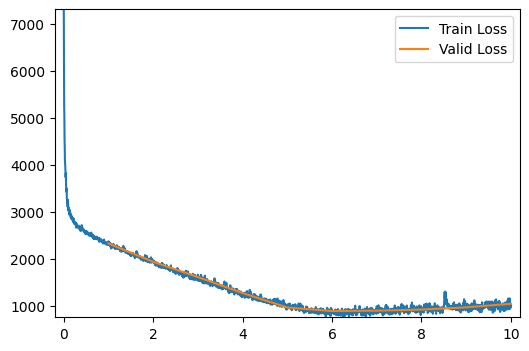

[10/10] Train Loss = 995.7704; Valid Loss = 1048.8625; Valid Accuracy = 0.0%


In [19]:
schedule  = NoiseSchedule().to(device)
VDM_model = VDMUNet().to(device)
vdm_loss  = make_vdm_loss(schedule)
1
run_model(data_path, VDM_model, learning_rate=0.003,
          get_output_and_loss=vdm_loss,
          extra_params=schedule.parameters())

Sampling: 100%|█████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 473.60it/s]


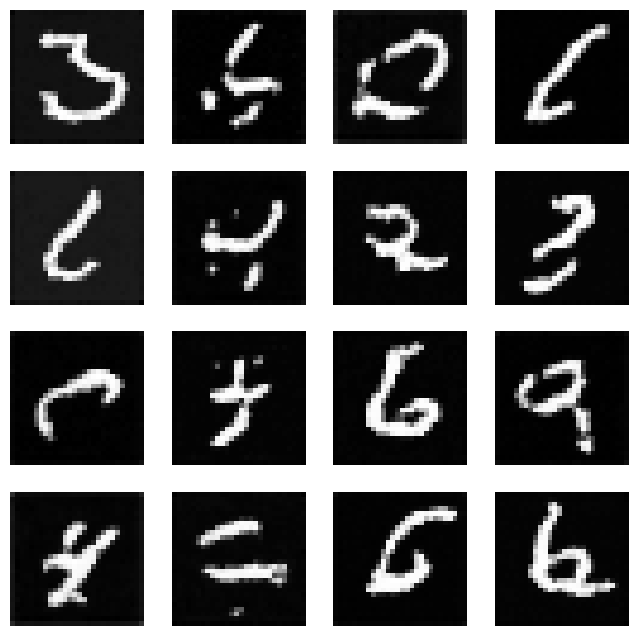

In [47]:
#@title Try sampling MNIST examples

X = sample_vdm(VDM_model, schedule,num_samples=16, steps=100)
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X[i][0].detach().cpu().numpy(), cmap='Greys_r')
    plt.axis('off')
plt.show()


In [33]:
import math
def evaluate_vlb_bpd(loss_fn, model, loader, device, label,
                     extra_args=None):
    total_loss = 0.
    total_n    = 0

    if extra_args is not None:
        for m in extra_args:
            if hasattr(m, 'eval'):
                m.eval()

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            B = X.size(0)
            batch_loss = 0.
            n_mc = 16
            for _ in range(n_mc):
                _, loss = loss_fn(model, X, y)
                batch_loss += loss.item()

            total_loss += (batch_loss / n_mc) * B
            total_n    += B

    mean_nll_nats = total_loss / total_n

    # Convert nats to bits per dimension
    image_shape = X.shape[1:]
    d = 1
    for s in image_shape:
        d *= s
    bpd = mean_nll_nats / (d * math.log(2))
    print(f"{label} BPD: {bpd:.4f}")
    return bpd


# Run evaluation on the test/validation set
_, valid_loader = get_fmnist_data_loaders(data_path, batch_size=256,
                                          valid_batch_size=256)

print("Evaluating BPD on validation set...\n")

vae_bpd  = evaluate_vlb_bpd(vae_vlb_loss,      vae_model,
                             valid_loader, device, "VAE")

diff_bpd = evaluate_vlb_bpd(diffusion_vlb_loss, unet_model,
                             valid_loader, device, "Diffusion")

vdm_loss = make_vdm_loss(schedule)
vdm_bpd  = evaluate_vlb_bpd(vdm_loss,           VDM_model,
                             valid_loader, device, "VDM",
                             extra_args=[schedule])

Evaluating BPD on validation set...

VAE BPD: 7.9275
Diffusion BPD: 8.4064
VDM BPD: 2.0089


In [22]:
print(f"gamma_min: {schedule.gamma_min.item():.3f}")
print(f"gamma_max: {schedule.gamma_max.item():.3f}")

gamma_min: -15.540
gamma_max: 6.197


In [23]:
#@title Compute BPD at varying T_eval

import math
from torch.func import jvp

LOG2 = math.log(2.0)

@torch.no_grad()
def vdm_bpd_at_T(model, schedule, loader, T, device, num_passes=16):
    model.eval()
    total_nelbo, total_n = 0.0, 0

    for _ in range(num_passes):
        for X, _ in loader:
            X = X.to(device)
            B = X.size(0)
            D = X[0].numel()
            if T == float('inf'):
                t = torch.rand(B, device=device) * 0.998 + 0.001
                g_t, g_t_grad = jvp(schedule, (t,), (torch.ones_like(t),))
                weight = 0.5 * g_t_grad
            else:
                i_idx = torch.randint(1, T + 1, (B,), device=device).float()
                t     = i_idx / T
                s     = (i_idx - 1) / T
                g_t   = schedule(t)
                g_s   = schedule(s)
                weight = 0.5 * T * (g_t - g_s).expm1()

            alpha_t = torch.sigmoid(-g_t).sqrt()
            sigma_t = torch.sigmoid( g_t).sqrt()
            eps     = torch.randn_like(X)
            z_t     = alpha_t[:, None, None, None] * X + sigma_t[:, None, None, None] * eps
            eps_hat = model(z_t, g_t)
            mse     = ((eps_hat - eps) ** 2).sum(dim=(1, 2, 3))
            diff_term = weight * mse

            t_one = torch.ones(B, device=device)
            g_1   = schedule(t_one)
            var_1 = torch.sigmoid(g_1)
            prior_term = 0.5 * (
                (1 - var_1)[:, None, None, None] * X ** 2
                + var_1[:, None, None, None]
                - 1.0
                - torch.log(var_1[:, None, None, None])
            ).sum(dim=(1, 2, 3))

            t_zero       = torch.zeros(B, device=device)
            g_0          = schedule(t_zero)
            log_sigma_0  = 0.5 * g_0[:, None, None, None]
            eps_0        = torch.randn_like(X)
            z_0_rescaled = X + log_sigma_0.exp() * eps_0
            recon_term   = -discretized_gaussian_logprob(X, z_0_rescaled,
                                                        log_sigma=log_sigma_0)

            nelbo = diff_term + prior_term + recon_term 
            total_nelbo += nelbo.sum().item()
            total_n     += B

    return (total_nelbo / total_n) / D / LOG2


T_eval_values = [10, 100, 250, 500, 1000, float('inf')]

_, eval_loader = get_fmnist_data_loaders(data_path, batch_size=256,
                                         valid_batch_size=256)

bpd_results = {}
for T in T_eval_values:
    label = '∞' if T == float('inf') else str(T)
    n_pass = 32 if (T == float('inf') or T <= 100) else 16
    print(f"T_eval = {label:>5s} ... ", end='', flush=True)
    bpd = vdm_bpd_at_T(VDM_model, schedule, eval_loader, T, device,
                       num_passes=n_pass)
    bpd_results[T] = bpd
    print(f"BPD = {bpd:.4f}")

T_eval =    10 ... BPD = 9.0311
T_eval =   100 ... BPD = 2.1648
T_eval =   250 ... BPD = 2.0102
T_eval =   500 ... BPD = 1.9617
T_eval =  1000 ... BPD = 1.9338
T_eval =     ∞ ... BPD = 1.9073


In [24]:
#Output Reuslts
print(f"{'T_train':>8s}  {'T_eval':>8s}  {'BPD':>8s}")
print('-' * 30)
for T, bpd in bpd_results.items():
    label = '∞' if T == float('inf') else str(T)
    print(f"{'∞':>8s}  {label:>8s}  {bpd:>8.4f}")


 T_train    T_eval       BPD
------------------------------
       ∞        10    9.0311
       ∞       100    2.1648
       ∞       250    2.0102
       ∞       500    1.9617
       ∞      1000    1.9338
       ∞         ∞    1.9073


# FashionMNIST

Training VAE on Fashion-MNIST


<div><p>[ 1/10] Train Loss = 4394.5888; Valid Loss = 4341.7012; Valid Accuracy = 0.0%</p><p>[ 2/10] Train Loss = 4332.9557; Valid Loss = 4325.5977; Valid Accuracy = 0.0%</p><p>[ 3/10] Train Loss = 4321.3532; Valid Loss = 4318.3047; Valid Accuracy = 0.0%</p><p>[ 4/10] Train Loss = 4317.2128; Valid Loss = 4317.2764; Valid Accuracy = 0.0%</p><p>[ 5/10] Train Loss = 4314.8502; Valid Loss = 4314.2744; Valid Accuracy = 0.0%</p><p>[ 6/10] Train Loss = 4313.5851; Valid Loss = 4314.1333; Valid Accuracy = 0.0%</p><p>[ 7/10] Train Loss = 4312.7661; Valid Loss = 4311.9326; Valid Accuracy = 0.0%</p><p>[ 8/10] Train Loss = 4311.8817; Valid Loss = 4312.6089; Valid Accuracy = 0.0%</p><p>[ 9/10] Train Loss = 4311.4143; Valid Loss = 4312.1309; Valid Accuracy = 0.0%</p><p>[10/10] Train Loss = 4310.8353; Valid Loss = 4311.2432; Valid Accuracy = 0.0%</p></div>

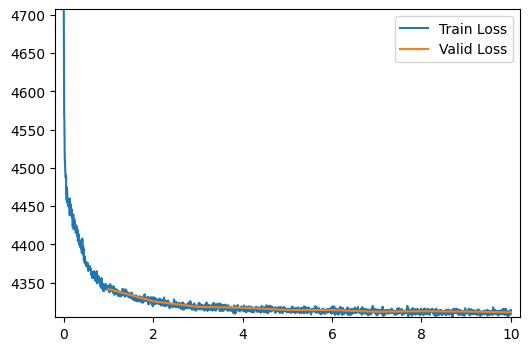

[10/10] Train Loss = 4310.8353; Valid Loss = 4311.2432; Valid Accuracy = 0.0%

Training basic diffusion on Fashion-MNIST


<div><p>[ 1/10] Train Loss = 14016.1718; Valid Loss = 6157.2124; Valid Accuracy = 0.0%</p><p>[ 2/10] Train Loss = 6078.3201; Valid Loss = 5524.1465; Valid Accuracy = 0.0%</p><p>[ 3/10] Train Loss = 5525.1312; Valid Loss = 5450.8633; Valid Accuracy = 0.0%</p><p>[ 4/10] Train Loss = 5392.6958; Valid Loss = 5233.8267; Valid Accuracy = 0.0%</p><p>[ 5/10] Train Loss = 5265.5877; Valid Loss = 5096.7178; Valid Accuracy = 0.0%</p><p>[ 6/10] Train Loss = 5159.8090; Valid Loss = 5204.6797; Valid Accuracy = 0.0%</p><p>[ 7/10] Train Loss = 5160.7452; Valid Loss = 5036.0522; Valid Accuracy = 0.0%</p><p>[ 8/10] Train Loss = 5096.4275; Valid Loss = 4951.3896; Valid Accuracy = 0.0%</p><p>[ 9/10] Train Loss = 5008.4135; Valid Loss = 4929.1831; Valid Accuracy = 0.0%</p><p>[10/10] Train Loss = 5012.7476; Valid Loss = 4961.0396; Valid Accuracy = 0.0%</p></div>

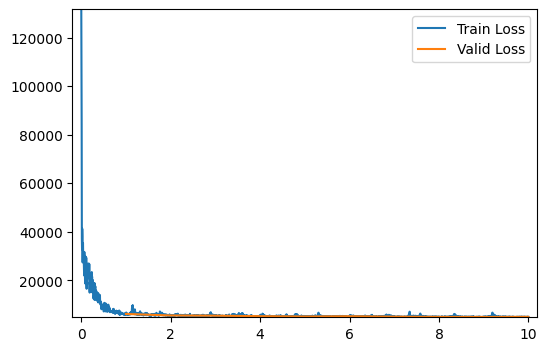

[10/10] Train Loss = 5012.7476; Valid Loss = 4961.0396; Valid Accuracy = 0.0%

Training VDM on Fashion-MNIST


<div><p>[ 1/10] Train Loss = 3102.4277; Valid Loss = 2763.4805; Valid Accuracy = 0.0%</p><p>[ 2/10] Train Loss = 2614.3967; Valid Loss = 2513.1689; Valid Accuracy = 0.0%</p><p>[ 3/10] Train Loss = 2372.7101; Valid Loss = 2260.2881; Valid Accuracy = 0.0%</p><p>[ 4/10] Train Loss = 2188.9056; Valid Loss = 2118.9609; Valid Accuracy = 0.0%</p><p>[ 5/10] Train Loss = 2019.7286; Valid Loss = 1979.7280; Valid Accuracy = 0.0%</p><p>[ 6/10] Train Loss = 1944.1892; Valid Loss = 1972.3363; Valid Accuracy = 0.0%</p><p>[ 7/10] Train Loss = 2007.5733; Valid Loss = 2034.8020; Valid Accuracy = 0.0%</p><p>[ 8/10] Train Loss = 2117.7610; Valid Loss = 2243.3901; Valid Accuracy = 0.0%</p><p>[ 9/10] Train Loss = 2141.0245; Valid Loss = 2153.0293; Valid Accuracy = 0.0%</p><p>[10/10] Train Loss = 2140.6498; Valid Loss = 2075.1611; Valid Accuracy = 0.0%</p></div>

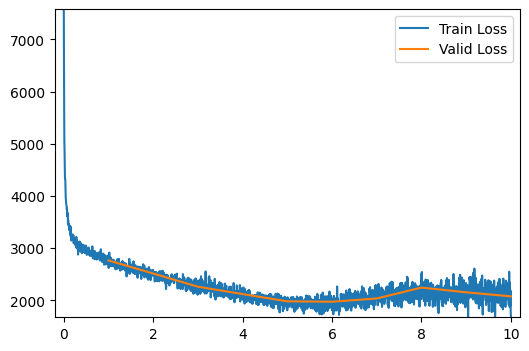

[10/10] Train Loss = 2140.6498; Valid Loss = 2075.1611; Valid Accuracy = 0.0%

Learned schedule endpoints: gamma_min = -13.532,  gamma_max = 6.245


In [25]:
#@title Fashion-MNIST: re-train all three core models from scratch

import copy

def get_fashionmnist_data_loaders(path, batch_size, valid_batch_size=0):
    """Mirror of get_fmnist_data_loaders but actually using FashionMNIST.
    The (0.286, 0.353) constants in your setup are already Fashion-MNIST stats."""
    data_mean, data_std = (0.2860,), (0.3530,)
    xforms = Compose([ToTensor(), Normalize(data_mean, data_std)])
    train_ds = FashionMNIST(root=path, train=True,  download=True, transform=xforms)
    valid_ds = FashionMNIST(root=path, train=False, download=True, transform=xforms)
    tbs = len(train_ds) if batch_size == 0 else batch_size
    vbs = len(valid_ds) if valid_batch_size == 0 else valid_batch_size
    return (DataLoader(train_ds, batch_size=tbs, shuffle=True),
            DataLoader(valid_ds, batch_size=vbs, shuffle=True))

fmnist_vae = copy.deepcopy(vae_model)
for m in fmnist_vae.modules():
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()
fmnist_vae = fmnist_vae.to(device)
fmnist_unet     = UNet().to(device)
fmnist_vdm      = VDMUNet().to(device)
fmnist_schedule = NoiseSchedule().to(device)
fmnist_vdm_loss = make_vdm_loss(fmnist_schedule)
fmnist_train, fmnist_valid = get_fashionmnist_data_loaders(data_path, batch_size)

print("Training VAE on Fashion-MNIST")
gradient_descent(fmnist_vae,  fmnist_train, fmnist_valid,
                 learning_rate=0.003, get_output_and_loss=vae_vlb_loss)

print("\nTraining basic diffusion on Fashion-MNIST")
gradient_descent(fmnist_unet, fmnist_train, fmnist_valid,
                 learning_rate=0.003, get_output_and_loss=diffusion_vlb_loss)

print("\nTraining VDM on Fashion-MNIST")
gradient_descent(fmnist_vdm,  fmnist_train, fmnist_valid,
                 learning_rate=0.003, get_output_and_loss=fmnist_vdm_loss,
                 extra_params=fmnist_schedule.parameters())

print(f"\nLearned schedule endpoints: "
      f"gamma_min = {fmnist_schedule.gamma_min.item():.3f},  "
      f"gamma_max = {fmnist_schedule.gamma_max.item():.3f}")

Sampling: 100%|█████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 224.33it/s]


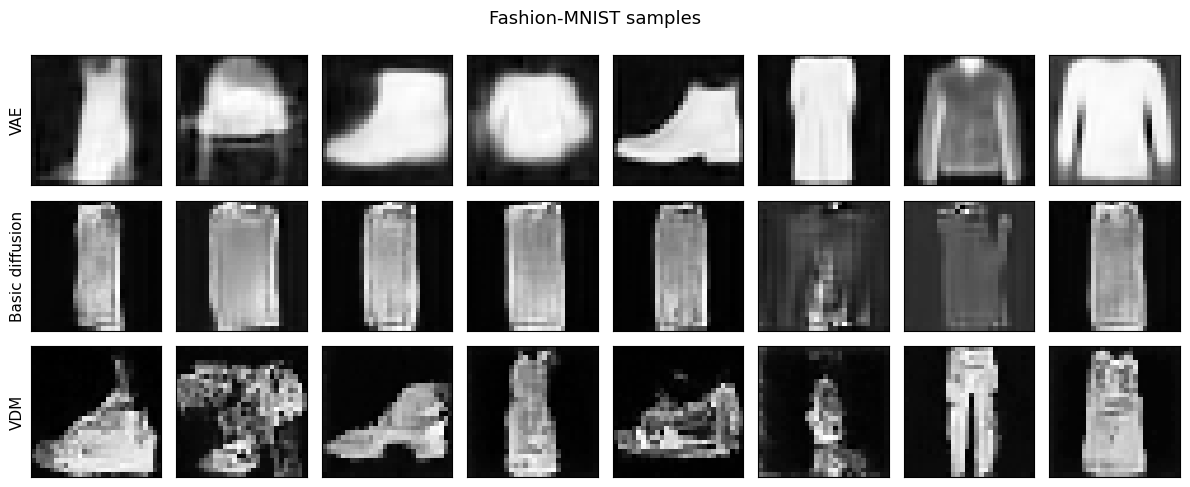

In [26]:
#sample display from all three models

vae_samples_fm  = fmnist_vae.sample(num_samples=8)
diff_samples_fm = sample_diffusion(fmnist_unet, num_samples=8, steps=100)
vdm_samples_fm  = sample_vdm(fmnist_vdm, fmnist_schedule, num_samples=8, steps=100)

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
rows = [
    ('VAE',             vae_samples_fm),
    ('Basic diffusion', diff_samples_fm),
    ('VDM',             vdm_samples_fm),
]
for r, (label, samples) in enumerate(rows):
    for c in range(8):
        ax = axes[r, c]
        ax.imshow(samples[c, 0].detach().cpu().numpy(), cmap='Greys_r')
        ax.set_xticks([]); ax.set_yticks([])
    axes[r, 0].set_ylabel(label, fontsize=11)
plt.suptitle('Fashion-MNIST samples', fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
#@title Fashion-MNIST: BPD comparison and T_eval table

print("Test-set BPD on Fashion-MNIST\n")
fm_vae_bpd  = evaluate_vlb_bpd(vae_vlb_loss,       fmnist_vae,
                                fmnist_valid, device, "VAE")
fm_diff_bpd = evaluate_vlb_bpd(diffusion_vlb_loss, fmnist_unet,
                                fmnist_valid, device, "Diffusion")
fm_vdm_bpd  = evaluate_vlb_bpd(fmnist_vdm_loss,    fmnist_vdm,
                                fmnist_valid, device, "VDM",
                                extra_args=[fmnist_schedule])

# VDM BPD vs T_eval
T_eval_values = [10, 100, 250, 500, 1000, float('inf')]
fmnist_T_results = {}
for T in T_eval_values:
    label  = '∞' if T == float('inf') else str(T)
    n_pass = 32 if (T == float('inf') or T <= 100) else 16
    bpd = vdm_bpd_at_T(fmnist_vdm, fmnist_schedule, fmnist_valid,
                       T, device, num_passes=n_pass)
    fmnist_T_results[T] = bpd
    print(f"T_eval = {label:>5s}  BPD = {bpd:.4f}")

print(f"\n{'T_train':>8s}  {'T_eval':>8s}  {'BPD':>8s}")
print('-' * 30)
for T, bpd in fmnist_T_results.items():
    label = '∞' if T == float('inf') else str(T)
    print(f"{'∞':>8s}  {label:>8s}  {bpd:>8.4f}")

Test-set BPD on Fashion-MNIST

VAE BPD: 7.9335
Diffusion BPD: 9.1116
VDM BPD: 3.8767
T_eval =    10  BPD = 23.0220
T_eval =   100  BPD = 4.4438
T_eval =   250  BPD = 4.1065
T_eval =   500  BPD = 3.9938
T_eval =  1000  BPD = 3.9244
T_eval =     ∞  BPD = 3.8694

 T_train    T_eval       BPD
------------------------------
       ∞        10   23.0220
       ∞       100    4.4438
       ∞       250    4.1065
       ∞       500    3.9938
       ∞      1000    3.9244
       ∞         ∞    3.8694


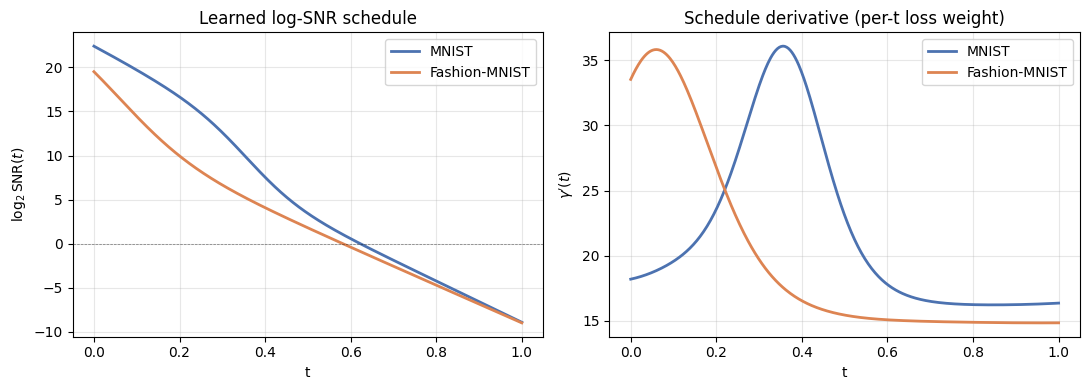

          MNIST  γ_min = -15.540   γ_max =  6.197   log₂ SNR ∈ [ -8.94,  22.42]
  Fashion-MNIST  γ_min = -13.532   γ_max =  6.245   log₂ SNR ∈ [ -9.01,  19.52]


In [28]:
#@title Plot the learned noise schedules

from torch.func import jvp

def get_schedule_curves(sched, n=500):
    t = torch.linspace(0., 1., n, device=device)
    g, g_prime = jvp(sched, (t,), (torch.ones_like(t),))
    return (t.cpu().numpy(),
            g.detach().cpu().numpy(),
            g_prime.detach().cpu().numpy())

t_grid, g_m, gp_m = get_schedule_curves(schedule)
_,      g_f, gp_f = get_schedule_curves(fmnist_schedule)

LOG2 = math.log(2.)
log2_snr_m = -g_m / LOG2
log2_snr_f = -g_f / LOG2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t_grid, log2_snr_m, label='MNIST',         color='#4C72B0', lw=2)
axes[0].plot(t_grid, log2_snr_f, label='Fashion-MNIST', color='#DD8452', lw=2)
axes[0].axhline(0, color='k', lw=0.5, ls='--', alpha=0.5)  # SNR = 1 line
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$\log_2 \mathrm{SNR}(t)$')
axes[0].set_title('Learned log-SNR schedule')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_grid, gp_m, label='MNIST',         color='#4C72B0', lw=2)
axes[1].plot(t_grid, gp_f, label='Fashion-MNIST', color='#DD8452', lw=2)
axes[1].set_xlabel('t')
axes[1].set_ylabel(r"$\gamma'(t)$")
axes[1].set_title("Schedule derivative (per-t loss weight)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learned_noise_schedules.png", dpi=300, bbox_inches="tight")
plt.show()

for name, sched in [('MNIST', schedule), ('Fashion-MNIST', fmnist_schedule)]:
    gmin, gmax = sched.gamma_min.item(), sched.gamma_max.item()
    print(f"{name:>15s}  γ_min = {gmin:>7.3f}   γ_max = {gmax:>6.3f}   "
          f"log₂ SNR ∈ [{-gmax/LOG2:>6.2f}, {-gmin/LOG2:>6.2f}]")

<div><p>[ 1/10] Train Loss = 2750.7072; Valid Loss = 2327.5142; Valid Accuracy = 0.0%</p><p>[ 2/10] Train Loss = 2135.5187; Valid Loss = 1934.1711; Valid Accuracy = 0.0%</p><p>[ 3/10] Train Loss = 1764.5718; Valid Loss = 1601.3887; Valid Accuracy = 0.0%</p><p>[ 4/10] Train Loss = 1422.6565; Valid Loss = 1255.2799; Valid Accuracy = 0.0%</p><p>[ 5/10] Train Loss = 1124.4176; Valid Loss = 1012.7142; Valid Accuracy = 0.0%</p><p>[ 6/10] Train Loss = 981.0619; Valid Loss = 993.1141; Valid Accuracy = 0.0%</p><p>[ 7/10] Train Loss = 934.3040; Valid Loss = 922.1134; Valid Accuracy = 0.0%</p><p>[ 8/10] Train Loss = 961.8953; Valid Loss = 986.3444; Valid Accuracy = 0.0%</p><p>[ 9/10] Train Loss = 1011.3371; Valid Loss = 1122.4678; Valid Accuracy = 0.0%</p><p>[10/10] Train Loss = 1075.1318; Valid Loss = 1045.3345; Valid Accuracy = 0.0%</p></div>

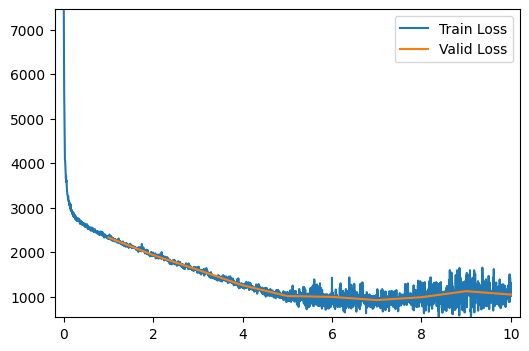

[10/10] Train Loss = 1075.1318; Valid Loss = 1045.3345; Valid Accuracy = 0.0%
VDM BPD: 1.9694


<div><p>[ 1/10] Train Loss = 2704.1341; Valid Loss = 2342.2539; Valid Accuracy = 0.0%</p><p>[ 2/10] Train Loss = 2143.2141; Valid Loss = 1974.7029; Valid Accuracy = 0.0%</p><p>[ 3/10] Train Loss = 1784.5373; Valid Loss = 1664.7991; Valid Accuracy = 0.0%</p><p>[ 4/10] Train Loss = 1476.5055; Valid Loss = 1331.4912; Valid Accuracy = 0.0%</p><p>[ 5/10] Train Loss = 1201.8414; Valid Loss = 1072.9270; Valid Accuracy = 0.0%</p><p>[ 6/10] Train Loss = 1107.2032; Valid Loss = 1237.1659; Valid Accuracy = 0.0%</p><p>[ 7/10] Train Loss = 1145.0414; Valid Loss = 1198.2643; Valid Accuracy = 0.0%</p><p>[ 8/10] Train Loss = 1258.5634; Valid Loss = 1294.6802; Valid Accuracy = 0.0%</p><p>[ 9/10] Train Loss = 1321.4698; Valid Loss = 1347.7219; Valid Accuracy = 0.0%</p><p>[10/10] Train Loss = 1351.7524; Valid Loss = 1582.0944; Valid Accuracy = 0.0%</p></div>

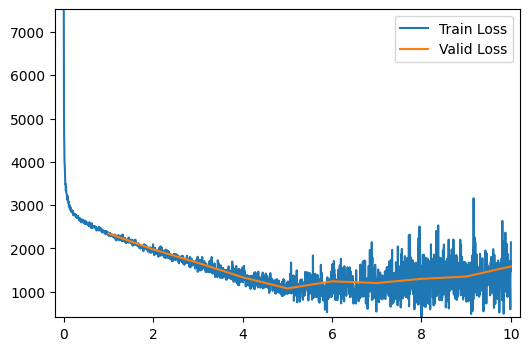

[10/10] Train Loss = 1351.7524; Valid Loss = 1582.0944; Valid Accuracy = 0.0%
VDM_No_Fourier BPD: 2.8521


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
schedule  = NoiseSchedule().to(device)
VDM_model = VDMUNet().to(device)
vdm_loss  = make_vdm_loss(schedule)
run_model(data_path, VDM_model, learning_rate=0.003,
          get_output_and_loss=vdm_loss,
          extra_params=schedule.parameters())
vdm_bpd  = evaluate_vlb_bpd(vdm_loss,           VDM_model,
                             valid_loader, device, "VDM",
                             extra_args=[schedule])


schedule_noFourier  = NoiseSchedule().to(device)
VDM_noFourier_model = UNet().to(device)
vdm_no_fourier_loss  = make_vdm_loss(schedule_noFourier)

run_model(
    data_path,
    VDM_noFourier_model,
    learning_rate=0.003,
    get_output_and_loss=vdm_no_fourier_loss,
    extra_params=schedule_noFourier.parameters()
)
vdm_bpd  = evaluate_vlb_bpd(vdm_no_fourier_loss,           VDM_noFourier_model,
                             valid_loader, device, "VDM_No_Fourier",
                             extra_args=[schedule_noFourier])